In [64]:
#WE TTRAIN KNN FOR OUR LOAN APPROVAL PREDICTION SYSTEM 
import pandas as pd
import pickle 

df= pd.read_csv("cleaned-2.csv")
df

,Unnamed: 0,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,business_or_commercial,loan_amount,rate_of_interest,...,credit_type,Credit_Score,LTV,Status,dtir1,loan_to_income,loan_to_collateral,interest_burden,total_cost_proxy,risk_score
0,0,cf,Sex Not Available,nopre,type1,p1,l1,nob/c,116500,3.990,...,EXP,758,98.728814,1,45.0,66.916,0.987,464835.0,467526.13,-16.8
1,1,cf,Male,nopre,type2,p1,l1,b/c,206500,3.990,...,EQUI,552,75.297619,1,40.0,41.458,0.494,823935.0,826626.13,104.8
2,2,cf,Male,pre,type1,p1,l1,nob/c,406500,4.560,...,EXP,834,80.019685,0,46.0,42.875,0.800,1853640.0,1854235.00,-62.0
3,3,cf,Male,nopre,type1,p4,l1,nob/c,456500,4.250,...,EXP,587,69.376900,0,42.0,38.423,0.694,1940125.0,1942816.13,84.6
4,4,cf,Joint,pre,type1,p1,l1,nob/c,696500,4.000,...,CRIF,602,91.886544,0,39.0,66.708,0.919,2786000.0,2786000.00,74.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1504,1504,cf,Joint,pre,type3,p1,l1,nob/c,236500,4.375,...,CIB,533,99.369748,0,44.0,40.214,0.994,1034687.5,1036987.50,117.8
1505,1505,cf,Sex Not Available,nopre,type3,p3,l1,nob/c,196500,3.990,...,EQUI,834,75.297619,1,40.0,72.751,0.470,784035.0,786726.13,-64.4
1506,1506,cf,Male,nopre,type2,p4,l1,b/c,116500,3.990,...,EXP,624,73.734177,1,26.0,49.765,0.737,464835.0,467526.13,56.0
1507,1507,cf,Male,nopre,type1,p3,l1,nob/c,136500,3.990,...,EXP,840,72.606383,0,38.0,45.485,0.726,544635.0,547745.38,-68.8


In [65]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import recall_score, f1_score , confusion_matrix , classification_report , confusion_matrix
df = pd.get_dummies(df, drop_first=True)
X = df.drop('Status', axis=1)
y = df['Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [66]:
#lets go for best k value 
recall_scores = []

for k in range(1, 11):
    model7 = KNeighborsClassifier(n_neighbors=k)
    model7.fit(X_train_scaled, y_train)
    pred = model7.predict(X_test_scaled)
    
    score = recall_score(y_test, pred)
    recall_scores.append(score)
    print(f"k={k}, Recall={score}")

k=1, Recall=0.6125
k=2, Recall=0.4
k=3, Recall=0.5
k=4, Recall=0.3875
k=5, Recall=0.475
k=6, Recall=0.375
k=7, Recall=0.4125
k=8, Recall=0.35
k=9, Recall=0.3875
k=10, Recall=0.3125


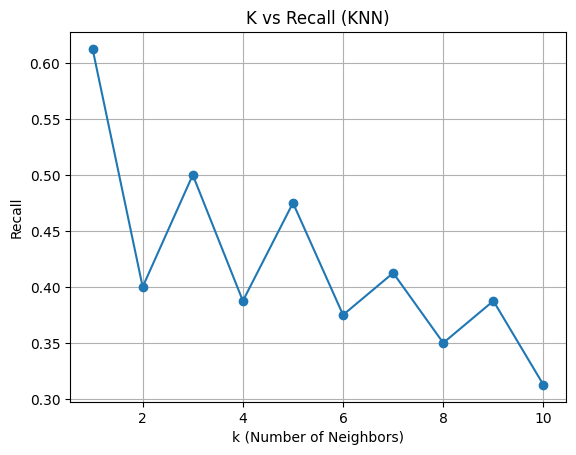

In [67]:
import matplotlib.pyplot as plt

k_values = list(range(1, 11))

plt.plot(k_values, recall_scores, marker='o')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Recall')
plt.title('K vs Recall (KNN)')
plt.grid()

plt.show()

In [55]:
best_k = 3
#TRAINNING MODEL ON ALL COLUMNS USING BEST K VALUE 
model_all = KNeighborsClassifier(n_neighbors=best_k)
model_all.fit(X_train_scaled, y_train)

pred_all = model_all.predict(X_test_scaled)

print("Recall:", recall_score(y_test, pred_all))
print("F1:", f1_score(y_test, pred_all))
print("Classification report \n" ,classification_report(y_test , pred_all))
print("confusion matrix: \n", confusion_matrix(y_test,pred_all))

Recall: 0.5
F1: 0.6106870229007634
Classification report 
               precision    recall  f1-score   support

           0       0.84      0.95      0.89       222
           1       0.78      0.50      0.61        80

    accuracy                           0.83       302
   macro avg       0.81      0.73      0.75       302
weighted avg       0.83      0.83      0.82       302

confusion matrix: 
 [[211  11]
 [ 40  40]]


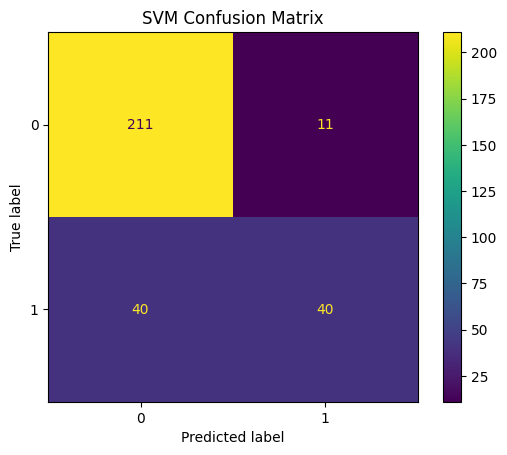

In [69]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, pred_all)
plt.title("SVM Confusion Matrix")
plt.show()

In [59]:
#choosing another value of k 
other_k=1
model_all1 = KNeighborsClassifier(n_neighbors=other_k)
model_all1.fit(X_train_scaled, y_train)

pred_all1 = model_all1.predict(X_test_scaled)

print("Recall:", recall_score(y_test, pred_all1))
print("F1:", f1_score(y_test, pred_all1))
print("Classification report \n" ,classification_report(y_test , pred_all1) )
print("confusion matrix: \n", confusion_matrix(y_test,pred_all))

Recall: 0.6125
F1: 0.6363636363636364
Classification report 
               precision    recall  f1-score   support

           0       0.86      0.89      0.88       222
           1       0.66      0.61      0.64        80

    accuracy                           0.81       302
   macro avg       0.76      0.75      0.76       302
weighted avg       0.81      0.81      0.81       302

confusion matrix: 
 [[211  11]
 [ 40  40]]


In [ ]:
#its always a better choice to use k=3 for final model as its stable and not sensitive as 1 is therefor we will use model_all

In [63]:
import pickle 
with open("knnmodel.plk", "wb")as f:
    pickle.dump(model_all , f)
print("Model saved")

Model saved


In [61]:
#now working on features which were finalised by backward/forward selection 
with open("features.pkl" , "rb") as f:
    features= pickle.load(f)
print("imported successfullly")

imported successfullly


In [32]:
df = pd.get_dummies(df, drop_first=True)
X_selected = df[features]  
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [33]:
recall_scores = []

for k in range(1, 11):
    model7 = KNeighborsClassifier(n_neighbors=k)
    model7.fit(X_train_scaled, y_train)
    pred = model7.predict(X_test_scaled)
    
    score = recall_score(y_test, pred)
    recall_scores.append(score)
    print(f"k={k}, Recall={score}")

k=1, Recall=0.4625
k=2, Recall=0.4125
k=3, Recall=0.4375
k=4, Recall=0.4125
k=5, Recall=0.4125
k=6, Recall=0.4
k=7, Recall=0.4125
k=8, Recall=0.4125
k=9, Recall=0.4125
k=10, Recall=0.4125


In [57]:
new_k=3 
model_sel = KNeighborsClassifier(n_neighbors=new_k)
model_sel.fit(X_train_scaled, y_train)

pred_sel = model_sel.predict(X_test_scaled)

print("Selected Features:")
print("Recall:", recall_score(y_test, pred_sel))
print("F1:", f1_score(y_test, pred_sel))
print("Classification report \n" ,classification_report(y_test , pred_sel) )
print("confusion matrix = \n", confusion_matrix(y_test,pred_sel))

Selected Features:
Recall: 0.5
F1: 0.6106870229007634
Classification report 
               precision    recall  f1-score   support

           0       0.84      0.95      0.89       222
           1       0.78      0.50      0.61        80

    accuracy                           0.83       302
   macro avg       0.81      0.73      0.75       302
weighted avg       0.83      0.83      0.82       302

confusion matrix = 
 [[211  11]
 [ 40  40]]


In [37]:
with open("pca.pkl", "rb") as f:
    pca = pickle.load(f)

In [39]:
from sklearn.decomposition import PCA
X = df.drop('Status', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

model_pca = KNeighborsClassifier(n_neighbors=best_k)
model_pca.fit(X_train_pca, y_train)

pred_pca = model_pca.predict(X_test_pca)

print("PCA Features:")
print("Recall:", recall_score(y_test, pred_pca))
print("F1:", f1_score(y_test, pred_pca))
print("Classification report \n" ,classification_report(y_test , pred_all) )

PCA Features:
Recall: 0.4625
F1: 0.556390977443609
Classification report 
               precision    recall  f1-score   support

           0       0.84      0.95      0.89       222
           1       0.78      0.50      0.61        80

    accuracy                           0.83       302
   macro avg       0.81      0.73      0.75       302
weighted avg       0.83      0.83      0.82       302

